# Notebook Instructions

1. If you are new to Jupyter notebooks, please go through this introductory manual <a href='https://quantra.quantinsti.com/quantra-notebook' target="_blank">here</a>.
1. Any changes made in this notebook would be lost after you close the browser window. **You can download the notebook to save your work on your PC.**
1. Before running this notebook on your local PC:<br>
i.  You need to set up a Python environment and the relevant packages on your local PC. To do so, go through the section on "**Run Codes Locally on Your Machine**" in the course.<br>
ii. You need to **download the zip file available in the last unit** of this course. The zip file contains the data files and/or python modules that might be required to run this notebook.

# Volatility Smile

In this notebook, we will create a trading strategy using a volatility smile on the Nifty call options.

## Importing libraries

Importing the relevant libraries for coding the strategy based on volatility smile. Mibian is used to compute implied volatilities, Pandas is used for taking advantage of its powerful dataframes and matplotlib.pyplot is used to plot the volatility smile.

In [1]:
from mibian import BS
import pandas as pd
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')

## Fetching data
We fetch data from a CSV file that contains call option data for a week of NIFTY50 call options expiring on Dec 28, 2017. We store this data in the dataframe nifty_data. Next, we define a new column in the dataframe with the header 'IV' and initialize it to 0. The implied volatilities will be stored under this header.


In [2]:
nifty_data = pd.read_csv('../data_modules/Option_data_NIFTY.csv')
nifty_data['IV'] = 0

## Computing implied volatilities
Here, we will be computing the implied volatilities by making use of a for loop and the BS function that we have imported earlier from the Mibian library. The values of implied volatilities are stored in the dataframe nifty_option under the column header 'IV'.

In [3]:
for row in range(0,len(nifty_data)):       
    underlyingPrice = nifty_data.iloc[row]['Underlying Value']
    strikePrice = nifty_data.iloc[row]['Strike Price']
    interestRate = 0
    daysToExpiration = nifty_data.iloc[row]['Time to Expiry']
    
    callPrice = nifty_data.iloc[row]['LTP']
    
    result = BS([underlyingPrice, strikePrice, interestRate, daysToExpiration],
                callPrice = callPrice)
    
    nifty_data.iloc[row,nifty_data.columns.get_loc('IV')] = result.impliedVolatility

## Defining Plot_smile function
Here, we will be defining a function to plot the smile for a particular date of the dataset by taking the value of the row index as its inputs. This function will be called later to plot the volatility smiles when we identify a bump or an anomaly. 


In [4]:
def Plot_smile(row):
    option_data = nifty_data[nifty_data['Date'] == nifty_data.iloc[row]['Date']]
    plt.plot(option_data['Strike Price'],option_data['IV'])
    plt.legend(option_data['Date'])
    plt.ylabel('Implied Volatility')
    plt.xlabel('Strike Price')           
    plt.show()

## Initializing columns
We then initialize the Signal, PNL and MTM columns with 0 values. These columns will be used to store the generation of trading signals, PNL and MTM of trades. 

In [5]:
nifty_data['Signal'] = 0
nifty_data['PNL'] = 0
nifty_data['MTM'] = 0

## Using a for loop for checking bumps in the volatility smile
We create a variable total_rows and then use a for loop to iterate over all the rows of the dataframe to identify a bump in the volatility smile curve. 

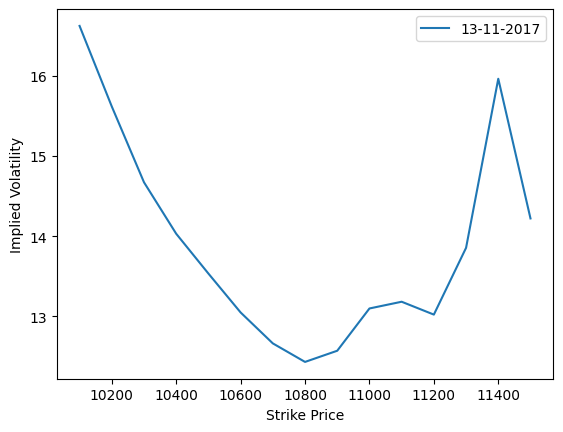

Position opened 
Date: 13-11-2017 
Strike Price: 11400 
 Money Received: INR 6.500000000000001


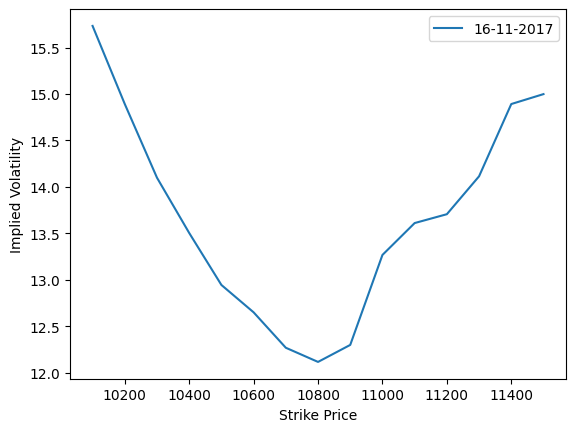

Position closed 
Date: 16-11-2017 
Strike Price: 11400 
 Money Paid: INR 0.6999999999999997


In [6]:
total_rows = len(nifty_data)
for row in range(1,total_rows -1):

# Identifying bumps in the volatility smile 
# In this part of the code, we will be opening trading positions if there are no open positions. 
# We check this using the value stored in the Signal column. A value of 0 implies that there are no open trading positions. 
# We then define 4 binomial variables storing True or False depending on the conditions:
# - ITM_check: If the underlying value is greater than the Strike Price, the option will be in the money
# - OTM_check: If the underlying value is less than the Strike Price, the option will be out of the money
# - same_day_check_ahead: This variable will store True if the dates for the current and the next rows are the same
# - same_day_check_behind: This variable will store True if the dates for the current and the previous rows are the same

# Moneyness and days will be checked for defining the condition for identifying an anomaly in the volatility smile.
    
    if nifty_data.iloc[row]['Signal'] == 0:
      
        ITM_check = nifty_data.iloc[row]['Underlying Value'] > nifty_data.iloc[row]['Strike Price'] 
        OTM_check = nifty_data.iloc[row]['Underlying Value'] < nifty_data.iloc[row]['Strike Price'] 
        same_day_check_ahead = nifty_data.iloc[row]['Date'] == nifty_data.iloc[row + 1]['Date']
        same_day_check_behind = nifty_data.iloc[row]['Date'] == nifty_data.iloc[row - 1]['Date']


# Generating Open Buy positions

# Here, we will be buying butterfly spreads once a bump or anomaly has been identified in the volatility smile. 
# The comments shown below will take you through how we identify trading opportunities.

# The first check is for in the money options and ensuring that the previous row data is of the same date 
        if ITM_check and same_day_check_behind:

            # Next, we check whether there is a bump in the smile. This is done by comparing the IV of 
            # higher strike (stored in a row) by the IV of lower strike (stored in the row -1) plus 1.5. 
            # The 1.5 term is added to include only the significant bumps as trading opportunities.
 
            if nifty_data.iloc[row]['IV'] > (nifty_data.iloc[row - 1]['IV'] + 1.5):
                
                # Setting signal to 1            
                nifty_data.iloc[row,nifty_data.columns.get_loc('Signal')] = 1 
                
                # Setting PNL to the cost of buying the butterfly spread, by writing two call options at 
                # the Strike of current row and buying call options at the strikes on rows ahead and behind
                # the current row.
                nifty_data.iloc[row,nifty_data.columns.get_loc('PNL')] = 2*nifty_data.iloc[row]['LTP'] \
                               - nifty_data.iloc[row + 1]['LTP'] - nifty_data.iloc[row - 1]['LTP']
                
                # Set Open_position to row, this variable will be used later to match the strike price,
                # while closing the open buy position.
                Open_position = row
                
                # Plotting smile by calling the Plot_smile() function
                Plot_smile(row)
                
                # Printing the output of the open position
                if nifty_data.iloc[row]['PNL'] > 0:
                    PnL = ["Money Received: INR", nifty_data.iloc[row]['PNL']]
                elif nifty_data.iloc[row]['PNL'] < 0:
                    PnL = ["Money Paid: INR", -nifty_data.iloc[row]['PNL']]
                print("Position opened", "\nDate:", nifty_data.iloc[row]['Date'], "\nStrike Price:", \
                       nifty_data.iloc[row]['Strike Price'], "\n",PnL[0],PnL[1])

# The second check is for out of the money options and ensuring that the next row data is of the same date 
        elif OTM_check and same_day_check_ahead:
            
            # Checking for a significant bump in the volatility smile.
            if nifty_data.iloc[row]['IV'] > (nifty_data.iloc[row + 1]['IV'] + 1.5):

                # Setting signal to 1                  
                nifty_data.iloc[row,nifty_data.columns.get_loc('Signal')] = 1
                
                # Setting PNL to the cost of buying the butterfly spread, by writing two call options at 
                # the strike of current row and buying call options at the strikes on rows ahead and behind
                # the current row.                
                nifty_data.iloc[row,nifty_data.columns.get_loc('PNL')] = 2*nifty_data.iloc[row]['LTP'] \
                               - nifty_data.iloc[row + 1]['LTP'] - nifty_data.iloc[row - 1]['LTP']
                # Set Open_position to row, this variable will be used later to match the strike price,
                # while closing the open buy position.
                Open_position = row
                
                # Plotting smile by calling the Plot_smile() function
                Plot_smile(row)
                
                # Printing the output of the open position
                if nifty_data.iloc[row]['PNL'] > 0:
                    PnL = ["Money Received: INR", nifty_data.iloc[row]['PNL']]
                elif nifty_data.iloc[row]['PNL'] < 0:
                    PnL = ["Money Paid: INR", -nifty_data.iloc[row]['PNL']]
                print("Position opened", "\nDate:", nifty_data.iloc[row]['Date'], "\nStrike Price:", \
                       nifty_data.iloc[row]['Strike Price'], "\n",PnL[0],PnL[1])

                    
# Closing positions by selling the spread

# We will now generate a sell signal by observing the smile curve regain its original expected shape, i.e. once the bump is removed.


# Check for an open position and the same Strike as that for which the open position was generated
    elif nifty_data.iloc[row]['Signal'] == 1 and nifty_data.iloc[row]['Strike Price'] == nifty_data.iloc[Open_position]['Strike Price']:
        
        # Checking whether the Option is in the money
        if nifty_data.iloc[row]['Underlying Value'] > nifty_data.iloc[row]['Strike Price']:
            
            # Checking whether the bump has gone
            if nifty_data.iloc[row]['IV'] < nifty_data.iloc[row - 1]['IV']:
                
                # Setting signal to 0
                nifty_data.iloc[row,nifty_data.columns.get_loc('Signal')] = 0
                
                # Setting the PNL by selling the spread
                nifty_data.iloc[row,nifty_data.columns.get_loc('PNL')] = - 2*nifty_data.iloc[row]['LTP'] \
                               + nifty_data.iloc[row + 1]['LTP'] + nifty_data.iloc[row - 1]['LTP']
                
                # Plotting the volatility smile
                Plot_smile(row)
                
                # Printing the output of selling a butterfly spread
                if nifty_data.iloc[row]['PNL'] > 0:
                    PnL = ["Money Received: INR", nifty_data.iloc[row]['PNL']]
                elif nifty_data.iloc[row]['PNL'] < 0:
                    PnL = ["Money Paid: INR", -nifty_data.iloc[row]['PNL']]
                print("Position closed", "\nDate:", nifty_data.iloc[row]['Date'], "\nStrike Price:", \
                       nifty_data.iloc[row]['Strike Price'],"\n",PnL[0],PnL[1])                             
        
        # Checking whether the Option is out of the money    
        elif nifty_data.iloc[row]['Underlying Value'] < nifty_data.iloc[row]['Strike Price']:
            
            # Checking whether the bump has gone
            if nifty_data.iloc[row]['IV'] < nifty_data.iloc[row + 1]['IV']:
                
                # Setting signal to 0
                nifty_data.iloc[row,nifty_data.columns.get_loc('Signal')] = 0
                
                # Setting the PNL by selling the spread
                nifty_data.iloc[row,nifty_data.columns.get_loc('PNL')] = - 2*nifty_data.iloc[row]['LTP'] \
                               + nifty_data.iloc[row + 1]['LTP'] + nifty_data.iloc[row - 1]['LTP']                  
                
                # Plotting the volatility smile
                Plot_smile(row)
                
                # Printing the output of selling a butterfly spread
                if nifty_data.iloc[row]['PNL'] > 0:
                    PnL = ["Money Received: INR", nifty_data.iloc[row]['PNL']]
                elif nifty_data.iloc[row]['PNL'] < 0:
                    PnL = ["Money Paid: INR", -nifty_data.iloc[row]['PNL']]
                print("Position closed", "\nDate:", nifty_data.iloc[row]['Date'], "\nStrike Price:", \
                       nifty_data.iloc[row]['Strike Price'],"\n",PnL[0],PnL[1])          

        # Computing MTM of trades
        # Here, we compute the MTM of trades, MTM is the mark to market value and it represents the value 
        # of the assets that we have purchased. The code below demonstrates the calculation. 
        # We then set the next value of Signal to be one, if the current value of Signal is one.
        nifty_data.iloc[row,nifty_data.columns.get_loc('MTM')] = 2*nifty_data.iloc[row]['LTP'] \
                               - nifty_data.iloc[row + 1]['LTP'] - nifty_data.iloc[row - 1]['LTP']
        
    if nifty_data.iloc[row]['Signal'] == 1:
        nifty_data.iloc[row+1,nifty_data.columns.get_loc('Signal')] = 1

## Computing cumulative PNL
Here, we compute the cumulative PNL by buying and selling the butterfly spread. We make use of the cumsum function.

In [7]:
nifty_data['Cumulative PNL'] = nifty_data.PNL.cumsum()

print("\n\nCumulative PNL from volatility smile trading strategy: INR", nifty_data.iloc[row]['Cumulative PNL'])



Cumulative PNL from volatility smile trading strategy: INR 5.800000000000001


In the upcoming units, you will practice these codes through interactive exercises.<br><br>